### STEP 1: IMPORT NECESSARY LIBRARIES

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

### STEP 2: LOAD THE DATA

In [44]:
train_df= pd.read_csv("../data/train.csv", na_values=['NA', 'N/A', ''])
test_df= pd.read_csv("../data/test.csv", na_values=['NA', 'N/A', ''])

print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)

train_df.sample(5)

Train Data Shape: (1460, 81)
Test Data Shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
907,908,50,RL,86.0,11500.0,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,250000
838,839,20,RL,75.0,9525.0,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,144000
698,699,20,RL,65.0,8450.0,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2010,WD,Normal,138500
1215,1216,20,RL,99.0,7094.0,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2007,WD,Normal,125000
732,733,60,RL,75.0,11404.0,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,222500


In [45]:
df= pd.concat((train_df, test_df))

In [46]:
df= df.drop("Id", axis= 1)

In [47]:
df.sample(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
660,60,RL,NaN,12384.0,Pave,NaN,Reg,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,197900.0
1273,20,RL,89.0,10858.0,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,MnPrv,NaN,0,7,2006,WD,Partial,NaN
767,20,RL,74.0,11563.0,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Normal,NaN
415,20,RL,73.0,8899.0,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,New,Partial,181134.0
688,20,RL,60.0,8089.0,Pave,NaN,Reg,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,392000.0


### STEP 3: SELECT IMPORTANT FEATURES

In [48]:
# I choose a small, meaningful set of features so the code stays easy to understand.  
# Later I will add more columns!


numeric_features= [
    "LotArea",
    "OverallQual",
    "OverallCond",
    "TotalBsmtSF",
    "TotRmsAbvGrd",
    "GarageArea",
    "GrLivArea",
    "YearBuilt",  
    "YearRemodAdd"
]

categorical_features=[
    "Neighborhood",
    "HouseStyle",
    "SaleCondition"
]

target= ["SalePrice"]

total_features= numeric_features+categorical_features

In [49]:
df[total_features].sample(5)

,LotArea,OverallQual,OverallCond,TotalBsmtSF,TotRmsAbvGrd,GarageArea,GrLivArea,YearBuilt,YearRemodAdd,Neighborhood,HouseStyle,SaleCondition
1073,7950.0,6,6,690.0,6,440.0,1426,1977,1977,Edwards,2Story,Normal
407,11422.0,8,5,1838.0,7,524.0,1838,2007,2008,CollgCr,1Story,Normal
1111,3907.0,8,5,1004.0,4,509.0,1020,1988,1988,Blueste,1Story,Normal
562,10759.0,5,4,1001.0,5,490.0,1641,1972,1972,Sawyer,1.5Fin,Normal
288,9819.0,5,5,882.0,5,280.0,900,1967,1967,Sawyer,1Story,Normal


### STEP 4: EDA

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   int64  
 1   MSZoning       2915 non-null   str    
 2   LotFrontage    2433 non-null   float64
 3   LotArea        2918 non-null   float64
 4   Street         2919 non-null   str    
 5   Alley          198 non-null    str    
 6   LotShape       2919 non-null   str    
 7   LandContour    2919 non-null   str    
 8   Utilities      2917 non-null   str    
 9   LotConfig      2919 non-null   str    
 10  LandSlope      2919 non-null   str    
 11  Neighborhood   2919 non-null   str    
 12  Condition1     2919 non-null   str    
 13  Condition2     2919 non-null   str    
 14  BldgType       2919 non-null   str    
 15  HouseStyle     2919 non-null   str    
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt      2919 non-

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df= df.reset_index(drop= True)

In [53]:
df[total_features].describe()

,LotArea,OverallQual,OverallCond,TotalBsmtSF,TotRmsAbvGrd,GarageArea,GrLivArea,YearBuilt,YearRemodAdd
count,2918.000000,2919.000000,2919.000000,2918.000000,2919.000000,2918.000000,2919.000000,2919.000000,2919.000000
mean,10168.702879,6.089072,5.564577,1051.777587,6.451524,472.874572,1500.759849,1971.312778,1984.264474
std,7888.283980,1.409947,1.113131,440.766258,1.569379,215.394815,506.051045,30.291442,20.894344
min,1300.000000,1.000000,1.000000,0.000000,2.000000,0.000000,334.000000,1872.000000,1950.000000
25%,7477.000000,5.000000,5.000000,793.000000,5.000000,320.000000,1126.000000,1953.500000,1965.000000
50%,9455.000000,6.000000,5.000000,989.500000,6.000000,480.000000,1444.000000,1973.000000,1993.000000
75%,11573.500000,7.000000,6.000000,1302.000000,7.000000,576.000000,1743.500000,2001.000000,2004.000000
max,215245.000000,10.000000,9.000000,6110.000000,15.000000,1488.000000,5642.000000,2010.000000,2010.000000


In [54]:
train_df[total_features].sample(5)

,LotArea,OverallQual,OverallCond,TotalBsmtSF,TotRmsAbvGrd,GarageArea,GrLivArea,YearBuilt,YearRemodAdd,Neighborhood,HouseStyle,SaleCondition
557,11040.0,4,6,637,7,570,1336,1920,1950,IDOTRR,1.5Fin,Normal
1442,11003.0,10,5,1017,10,812,2007,2008,2008,Somerst,2Story,Normal
37,8532.0,5,6,1297,5,498,1297,1954,1990,NAmes,1Story,Normal
61,7200.0,5,7,530,6,288,1111,1920,1996,IDOTRR,2.5Unf,Normal
502,9170.0,5,7,1214,6,461,1214,1965,1965,Edwards,1Story,Normal


In [55]:
df[total_features].isnull().sum()

LotArea          1
OverallQual      0
OverallCond      0
TotalBsmtSF      1
TotRmsAbvGrd     0
GarageArea       1
GrLivArea        0
YearBuilt        0
YearRemodAdd     0
Neighborhood     0
HouseStyle       0
SaleCondition    0
dtype: int64

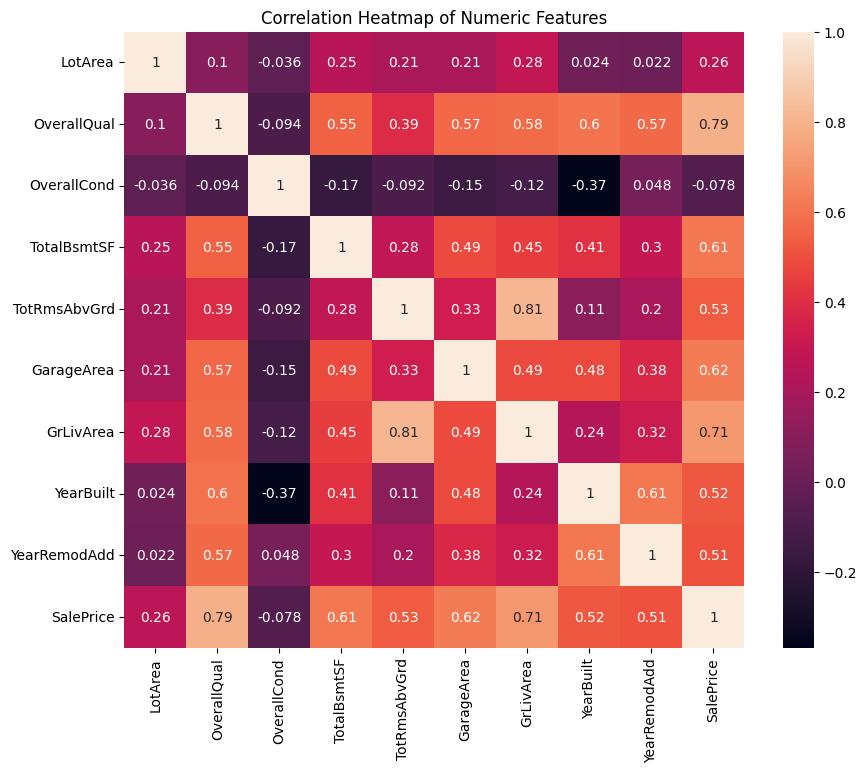

In [56]:
plt.figure(figsize= (10,8))
sns.heatmap(df[numeric_features+ target].corr(), annot= True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

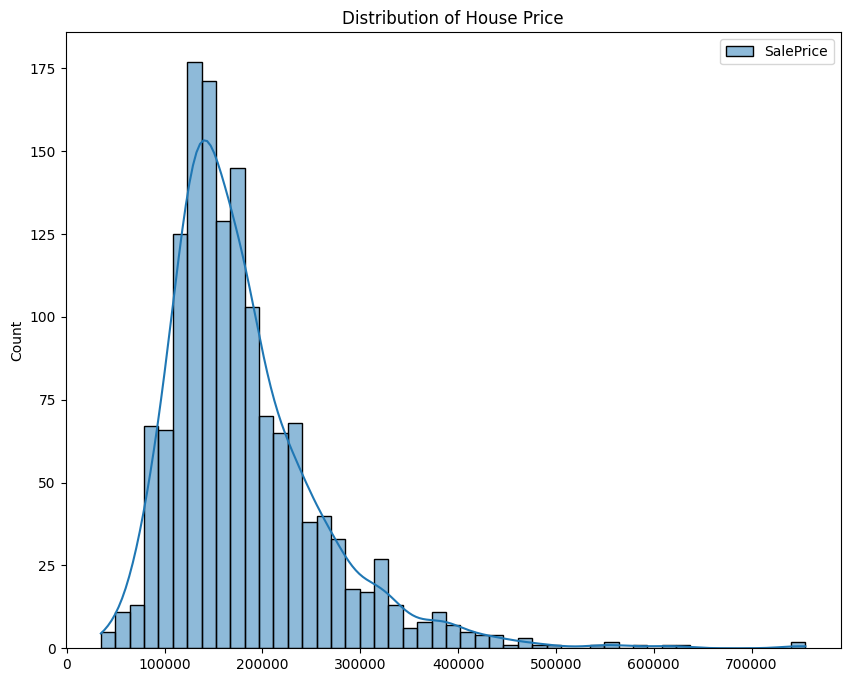

In [57]:
plt.figure(figsize= (10,8))
sns.histplot(df[target], kde= True)
plt.title("Distribution of House Price")
plt.show()

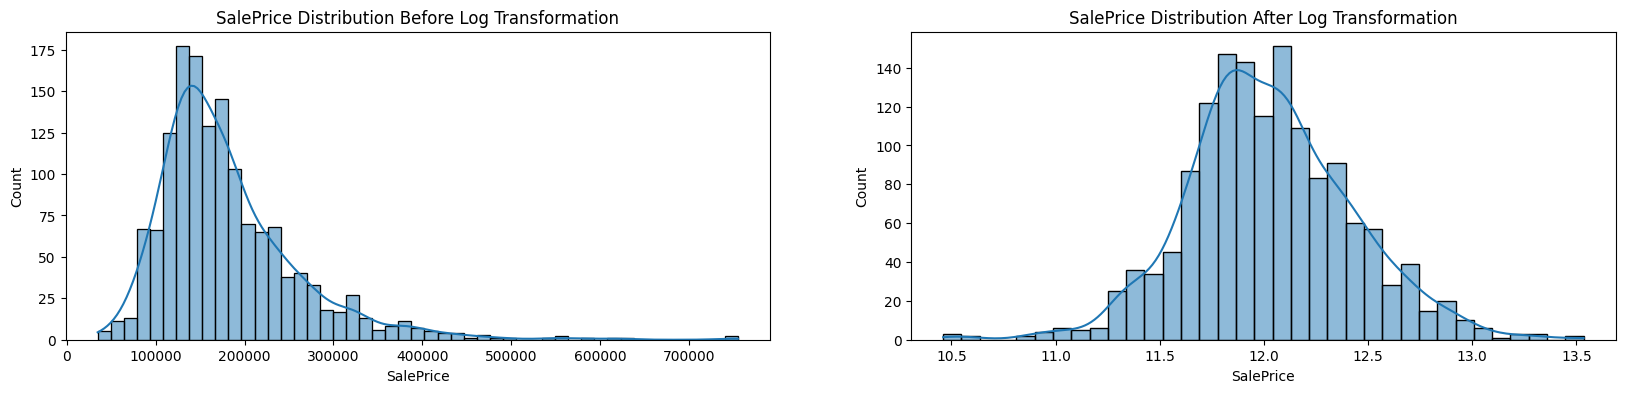

In [58]:
fig, axes= plt.subplots(1,2, figsize=(20,4))
sns.histplot(x= train_df["SalePrice"], kde= True, ax=axes[0])
axes[0].set_title("SalePrice Distribution Before Log Transformation")

sns.histplot(x= np.log1p(train_df["SalePrice"]), kde= True, ax=axes[1])
axes[1].set_title("SalePrice Distribution After Log Transformation")
plt.show()


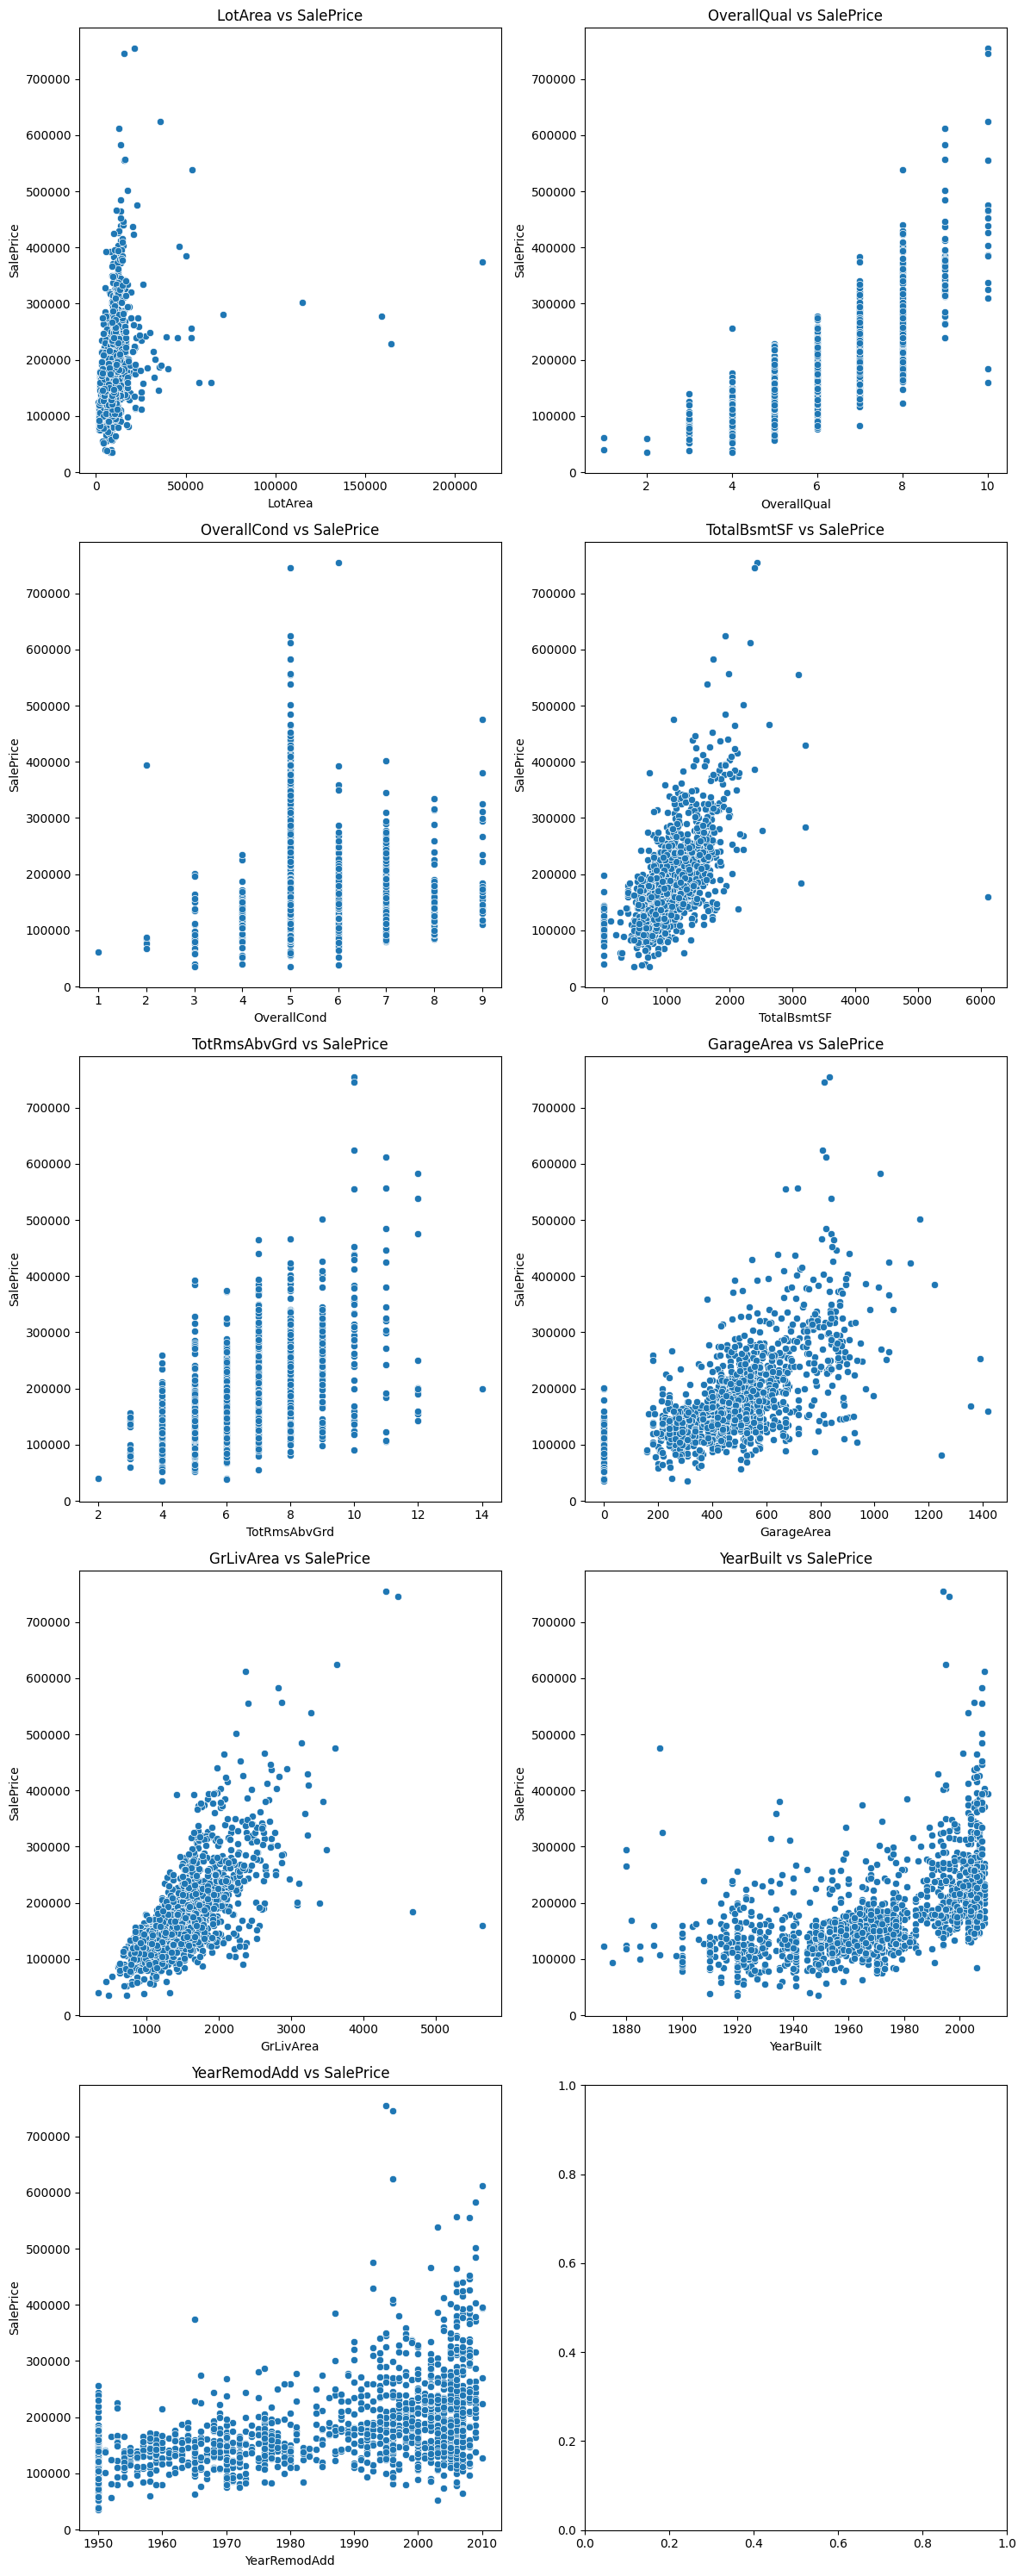

In [59]:
import math

fig, axes = plt.subplots(math.ceil(len(numeric_features)/2), 2, figsize=(12, 30))
axes= axes.flatten()
# axes is NOT a simple list, it is a 2D array (grid) like this:
# axes =
# [
#   [ax00, ax01],
#   [ax10, ax11],
#   [ax20, ax21]
# ]
# so we used flatten() to make it 1D which makes easy to access it.
for i in range(len(numeric_features)):
    col = numeric_features[i]
    sns.scatterplot(x=df[col], y=df["SalePrice"], ax=axes[i])
    axes[i].set_title(f"{col} vs SalePrice")
plt.tight_layout()
plt.show()

In [60]:
# HANDLING MISSING VALUES MANUALLY.

# def missing_values(df):
#     df= df.copy()
    
#     for col in numeric_features:
#         df[col]= df[col].fillna(df[col].median())

#     for col in categorical_features:
#         df[col]= df[col].fillna(df[col].mode()[0])
            
#     return df

# train_df= missing_values(train_df[total_features])
# test_df= missing_values(test_df[total_features])

##### We can handle missing values using simple imputer in sklearn.

### STEP 5: SEPARATE TRAIN AND VALIDATION DATA

In [61]:
X= train_df[total_features]
y= np.log1p(train_df[target])

X_train, X_val, y_train, y_val= train_test_split(X, y, test_size= 0.2, random_state= 42)
y_val_actual = np.expm1(y_val)  
y_train.shape
y_train = y_train.values.ravel()
y_train.shape

(1168,)

### STEP 6: MODEL TRAINING

In [62]:
numeric_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='median')),   
        ('scalar', StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor= ColumnTransformer(
    [
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

#### MODEL TRAINING USING LINEAR REGRESSION

In [63]:
model1= Pipeline(
    [
        ('preprocessor', preprocessor),
        ('lrmodel', LinearRegression())
    ]
)

In [64]:
cv_scores1 = cross_val_score(
    model1,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV scores:", np.round(cv_scores1, 2))
print("Average :", np.round(cv_scores1.mean(), 2))

CV scores: [0.88 0.81 0.76 0.87 0.87]
Average : 0.84


In [65]:
model1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lrmodel', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [66]:
y_pred1= model1.predict(X_val)
y_pred1[:10]

array([11.9633537 , 12.68705176, 11.57259865, 11.98616307, 12.57984724,
       11.31608597, 12.4395955 , 11.8978184 , 11.30946186, 11.79239558])

#### MODEL TRAINING USING RANDOMFOREST REGRESSOR

In [67]:
model2= Pipeline(
    [
        ('preprocessor', preprocessor),
        ('rfmodel', RandomForestRegressor(n_estimators= 100, max_depth= 10, random_state= 42))
    ]
)

In [68]:
cv_scores2 = cross_val_score(
    model2,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV scores:", np.round(cv_scores2, 2))
print("Average :", np.round(cv_scores2.mean(), 2))

CV scores: [0.88 0.79 0.85 0.85 0.88]
Average : 0.85


In [69]:
model2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rfmodel', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [70]:
y_pred2= model2.predict(X_val)
y_pred2[:10]

array([11.84447367, 12.71794847, 11.64340123, 12.00441004, 12.63731855,
       11.29538612, 12.27087693, 11.94382668, 11.28316411, 11.83830346])

#### MODEL TRAINING USING XGBOOST

In [71]:
model3 = Pipeline([
    ('preprocessor', preprocessor),
    ('xgbmodel', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [72]:
cv_scores3 = cross_val_score(
    model3,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV scores:", np.round(cv_scores3, 2))
print("Average :", np.round(cv_scores3.mean(), 2))

CV scores: [0.89 0.83 0.88 0.87 0.9 ]
Average : 0.88


In [73]:
model3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xgbmodel', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [74]:
y_pred3= model3.predict(X_val)
y_pred3[:10]

array([11.887562, 12.73908 , 11.57916 , 11.958727, 12.705622, 11.261438,
       12.394138, 11.916487, 11.255611, 11.887331], dtype=float32)

### STEP 7: MODEL EVALUATION

In [75]:
y_pred1= np.expm1(model1.predict(X_val))
model1_rmse= np.sqrt(mean_squared_error(y_val_actual, y_pred1))
model1_r2= r2_score(y_val_actual, y_pred1)
print(f"Linear Regression  →  RMSE: ${model1_rmse:,.0f}  |  R²: {model1_r2:.2f}")

y_pred2 = np.expm1(model2.predict(X_val))
model2_rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred2))
model2_r2   = r2_score(y_val_actual, y_pred2)
print(f"Random Forest      →  RMSE: ${model2_rmse:,.0f}  |  R²: {model2_r2:.2f}")

y_pred3 = np.expm1(model3.predict(X_val))
model3_rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred3))
model3_r2   = r2_score(y_val_actual, y_pred3)
print(f"XGBoost            →  RMSE: ${model3_rmse:,.0f}  |  R²: {model3_r2:.2f}")

Linear Regression  →  RMSE: $28,634  |  R²: 0.89
Random Forest      →  RMSE: $30,218  |  R²: 0.88
XGBoost            →  RMSE: $25,781  |  R²: 0.91


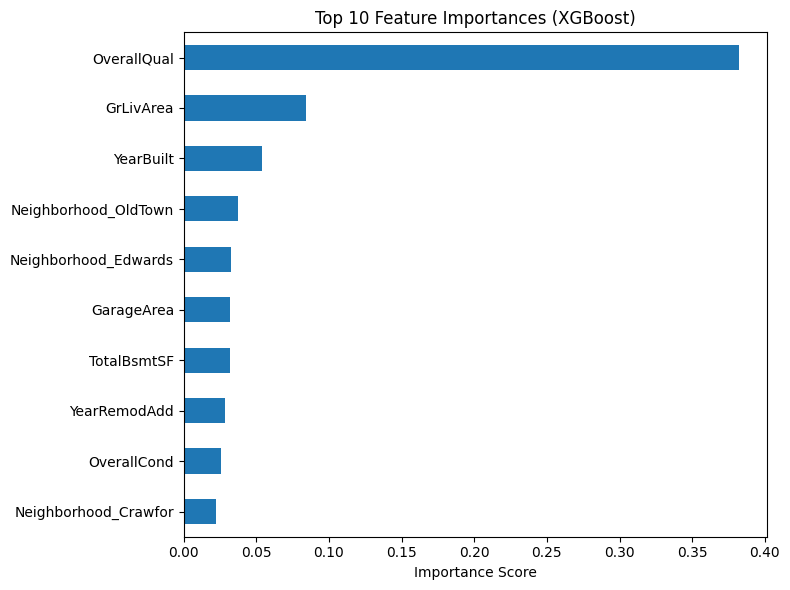

In [76]:
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features))

importances = pd.Series(model3.named_steps['xgbmodel'].feature_importances_,index=feature_names).sort_values(ascending=True).tail(10)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [77]:
pred= np.expm1(model3.predict(test_df[total_features]))

# Prediction file
prediction= pd.DataFrame({"ID": pd.read_csv("../data/test.csv")['Id'],
                         "SalePrice": pred})
prediction.to_csv("../data/prediction.csv", index= False)

In [79]:
import joblib

# save
joblib.dump(model3, "../model/house_price_model.pkl")

# load
model = joblib.load("../model/house_price_model.pkl")